<a href="https://colab.research.google.com/github/SrishanthGorla/SERAI/blob/main/Controlled_data_poisoning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

class_names = iris.target_names

print("Dataset shape:", X.shape)
print("Number of classes:", len(class_names))
print("Classes:", class_names)

Dataset shape: (150, 4)
Number of classes: 3
Classes: ['setosa' 'versicolor' 'virginica']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [5]:
clean_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

clean_model.fit(X_train, y_train)

y_pred_clean = clean_model.predict(X_test)

print("Clean model trained successfully.")

Clean model trained successfully.


In [6]:
clean_accuracy = accuracy_score(y_test, y_pred_clean)

clean_precision = precision_score(
    y_test,
    y_pred_clean,
    average="weighted"
)

clean_recall = recall_score(
    y_test,
    y_pred_clean,
    average="weighted"
)

clean_f1 = f1_score(
    y_test,
    y_pred_clean,
    average="weighted"
)

print("CLEAN MODEL PERFORMANCE")
print("-----------------------")
print("Accuracy :", round(clean_accuracy, 4))
print("Precision:", round(clean_precision, 4))
print("Recall   :", round(clean_recall, 4))
print("F1-score :", round(clean_f1, 4))

CLEAN MODEL PERFORMANCE
-----------------------
Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1-score : 0.9333


In [7]:
# Reproducible random selection
rng = np.random.RandomState(42)

# Number of contaminated records
n_poison = 18

# Select records only from the training set
poison_indices = rng.choice(
    len(X_train),
    size=n_poison,
    replace=False
)

# Copy selected training records
X_poison = X_train[poison_indices].copy()
y_poison_original = y_train[poison_indices].copy()

# Change the labels to an incorrect class
# This simulates controlled label poisoning
y_poison = (y_poison_original + 1) % 3

print("Number of contaminated records:", len(X_poison))
print("\nOriginal labels:")
print(y_poison_original)

print("\nPoisoned labels:")
print(y_poison)

Number of contaminated records: 18

Original labels:
[0 0 1 2 2 1 2 2 0 1 2 2 1 1 0 2 1 0]

Poisoned labels:
[1 1 2 0 0 2 0 0 1 2 0 0 2 2 1 0 2 1]


In [8]:
poison_df = pd.DataFrame(
    X_poison,
    columns=iris.feature_names
)

poison_df["Original Label"] = [
    class_names[i] for i in y_poison_original
]

poison_df["Poisoned Label"] = [
    class_names[i] for i in y_poison
]

poison_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Original Label,Poisoned Label
0,4.9,3.0,1.4,0.2,setosa,versicolor
1,5.0,3.2,1.2,0.2,setosa,versicolor
2,5.5,2.5,4.0,1.3,versicolor,virginica
3,5.9,3.0,5.1,1.8,virginica,setosa
4,6.4,2.7,5.3,1.9,virginica,setosa
5,6.0,2.7,5.1,1.6,versicolor,virginica
6,6.0,2.2,5.0,1.5,virginica,setosa
7,7.6,3.0,6.6,2.1,virginica,setosa
8,4.6,3.4,1.4,0.3,setosa,versicolor
9,5.7,3.0,4.2,1.2,versicolor,virginica


In [9]:
# Add poisoned records ONLY to the training set
X_train_poisoned = np.vstack([
    X_train,
    X_poison
])

y_train_poisoned = np.concatenate([
    y_train,
    y_poison
])

print("Original training size:", len(X_train))
print("Poisoned training size:", len(X_train_poisoned))
print("Test size:", len(X_test))

Original training size: 120
Poisoned training size: 138
Test size: 30


In [10]:
poisoned_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

poisoned_model.fit(
    X_train_poisoned,
    y_train_poisoned
)

y_pred_poisoned = poisoned_model.predict(X_test)

print("Poisoned model trained successfully.")

Poisoned model trained successfully.


In [11]:
poisoned_accuracy = accuracy_score(
    y_test,
    y_pred_poisoned
)

poisoned_precision = precision_score(
    y_test,
    y_pred_poisoned,
    average="weighted"
)

poisoned_recall = recall_score(
    y_test,
    y_pred_poisoned,
    average="weighted"
)

poisoned_f1 = f1_score(
    y_test,
    y_pred_poisoned,
    average="weighted"
)

print("POISONED MODEL PERFORMANCE")
print("--------------------------")
print("Accuracy :", round(poisoned_accuracy, 4))
print("Precision:", round(poisoned_precision, 4))
print("Recall   :", round(poisoned_recall, 4))
print("F1-score :", round(poisoned_f1, 4))

POISONED MODEL PERFORMANCE
--------------------------
Accuracy : 0.9
Precision: 0.9024
Recall   : 0.9
F1-score : 0.8997


In [12]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Clean Model": [
        clean_accuracy,
        clean_precision,
        clean_recall,
        clean_f1
    ],

    "Poisoned Model": [
        poisoned_accuracy,
        poisoned_precision,
        poisoned_recall,
        poisoned_f1
    ]
})

comparison["Change"] = (
    comparison["Poisoned Model"] -
    comparison["Clean Model"]
)

comparison.round(4)

,Metric,Clean Model,Poisoned Model,Change
0,Accuracy,0.9333,0.9000,-0.0333
1,Precision,0.9333,0.9024,-0.0310
2,Recall,0.9333,0.9000,-0.0333
3,F1-score,0.9333,0.8997,-0.0336


In [13]:
clean_report = classification_report(
    y_test,
    y_pred_clean,
    target_names=class_names,
    output_dict=True
)

poisoned_report = classification_report(
    y_test,
    y_pred_poisoned,
    target_names=class_names,
    output_dict=True
)

class_comparison = pd.DataFrame({
    "Class": class_names,

    "Clean Precision": [
        clean_report[c]["precision"] for c in class_names
    ],

    "Poisoned Precision": [
        poisoned_report[c]["precision"] for c in class_names
    ],

    "Clean Recall": [
        clean_report[c]["recall"] for c in class_names
    ],

    "Poisoned Recall": [
        poisoned_report[c]["recall"] for c in class_names
    ],

    "Clean F1": [
        clean_report[c]["f1-score"] for c in class_names
    ],

    "Poisoned F1": [
        poisoned_report[c]["f1-score"] for c in class_names
    ]
})

class_comparison.round(4)

,Class,Clean Precision,Poisoned Precision,Clean Recall,Poisoned Recall,Clean F1,Poisoned F1
0,setosa,1.0,1.0000,1.0,1.0,1.0,1.0000
1,versicolor,0.9,0.8889,0.9,0.8,0.9,0.8421
2,virginica,0.9,0.8182,0.9,0.9,0.9,0.8571


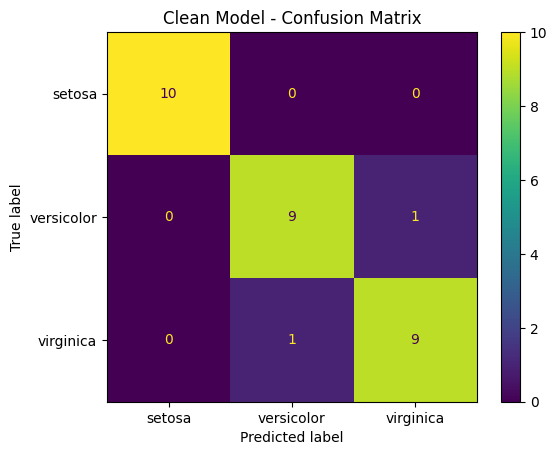

In [14]:
cm_clean = confusion_matrix(
    y_test,
    y_pred_clean
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_clean,
    display_labels=class_names
)

disp.plot()
plt.title("Clean Model - Confusion Matrix")
plt.show()

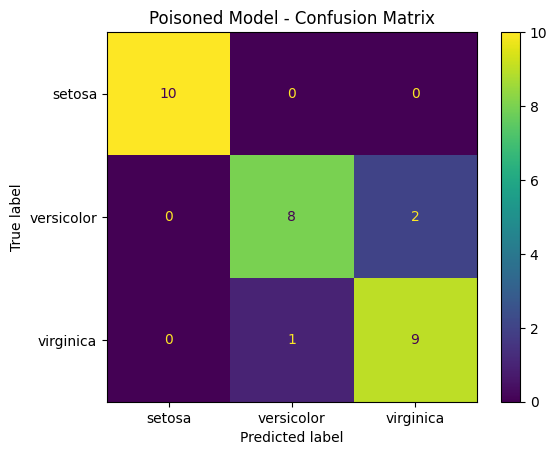

In [15]:
cm_poisoned = confusion_matrix(
    y_test,
    y_pred_poisoned
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_poisoned,
    display_labels=class_names
)

disp.plot()
plt.title("Poisoned Model - Confusion Matrix")
plt.show()

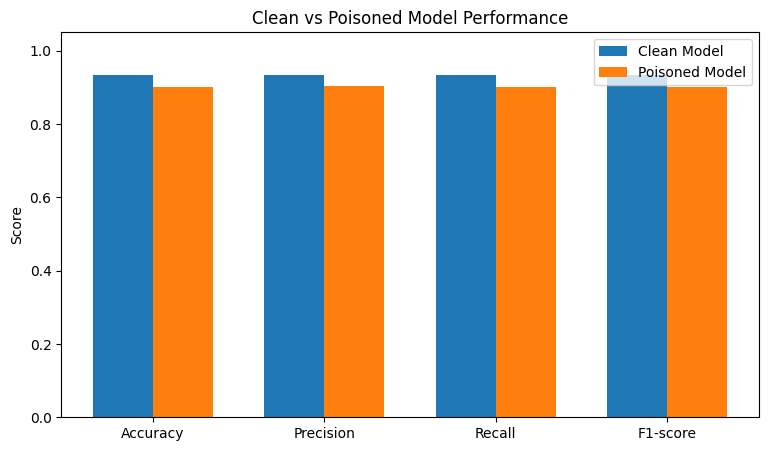

In [16]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

clean_values = [
    clean_accuracy,
    clean_precision,
    clean_recall,
    clean_f1
]

poisoned_values = [
    poisoned_accuracy,
    poisoned_precision,
    poisoned_recall,
    poisoned_f1
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    clean_values,
    width,
    label="Clean Model"
)

plt.bar(
    x + width/2,
    poisoned_values,
    width,
    label="Poisoned Model"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Clean vs Poisoned Model Performance")
plt.legend()

plt.show()

In [17]:
degradation = pd.DataFrame({
    "Metric": metrics,

    "Clean": clean_values,

    "Poisoned": poisoned_values,

    "Change": np.array(poisoned_values) - np.array(clean_values)
})

degradation["Percentage Change"] = (
    degradation["Change"] /
    degradation["Clean"]
) * 100

degradation.round(4)

,Metric,Clean,Poisoned,Change,Percentage Change
0,Accuracy,0.9333,0.9000,-0.0333,-3.5714
1,Precision,0.9333,0.9024,-0.0310,-3.3189
2,Recall,0.9333,0.9000,-0.0333,-3.5714
3,F1-score,0.9333,0.8997,-0.0336,-3.5983


In [18]:
print("===== CLEAN MODEL =====")
print(
    classification_report(
        y_test,
        y_pred_clean,
        target_names=class_names
    )
)

print("\n===== POISONED MODEL =====")
print(
    classification_report(
        y_test,
        y_pred_poisoned,
        target_names=class_names
    )
)

===== CLEAN MODEL =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


===== POISONED MODEL =====
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

